**BH-Binaries Channel Formation**

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

In [ ]:
load = np.load("../Solutions/formationchannels.npy")

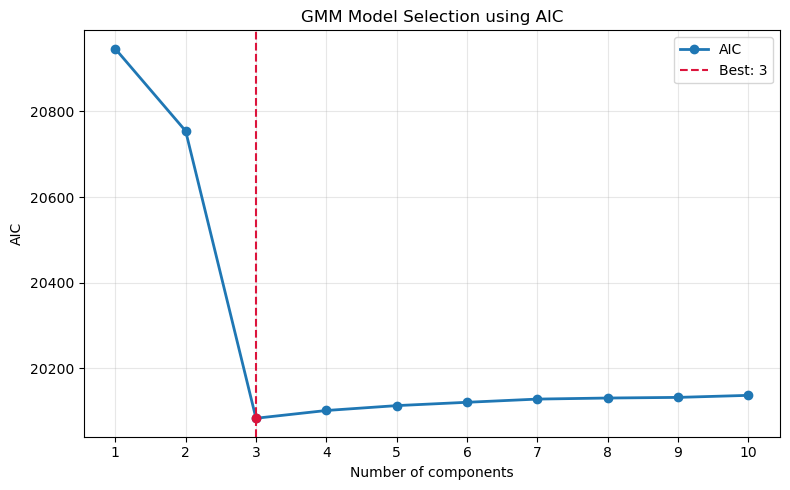

In [21]:
#AIC is a model selection criterion that balances model fit and complexity. 

x = load if load.ndim == 2 else load.reshape(-1, 1)
n_aic = np.zeros(10)

for n in range(10):
    gmm = GaussianMixture(n_components=n + 1, covariance_type='full', random_state=42)
    gmm.fit(x)
    n_aic[n] = gmm.aic(x)


components = np.arange(1, 11)
best_n = components[np.argmin(n_aic)]

plt.figure(figsize=(8, 5))
plt.plot(components, n_aic, marker='o', linewidth=2, label='AIC')
plt.axvline(best_n, color='crimson', linestyle='--', linewidth=1.5, label=f'Best: {best_n}')
plt.scatter(best_n, n_aic[best_n - 1], color='crimson', zorder=3)

plt.xticks(components)
plt.xlabel("Number of components")
plt.ylabel("AIC")
plt.title("GMM Model Selection using AIC")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

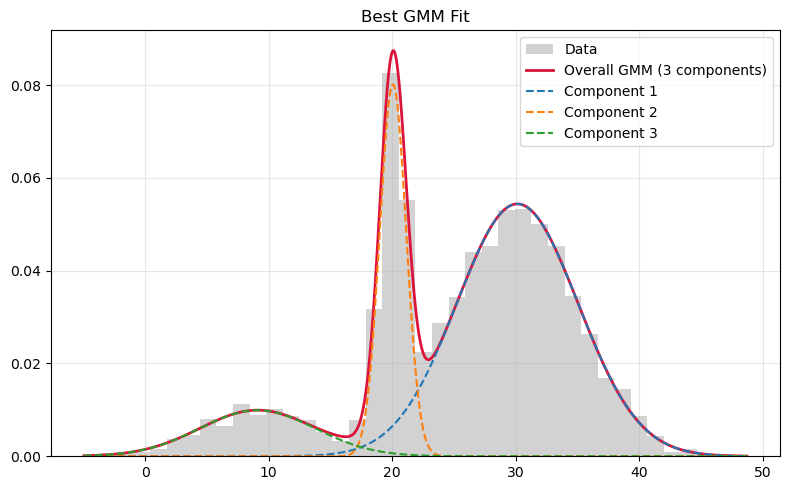

In [23]:
# Fit best GMM and plot results
gmm_best = GaussianMixture(n_components=int(best_n), covariance_type='full', random_state=42)
gmm_best.fit(x)

xx = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)
pdf = np.exp(gmm_best.score_samples(xx))
resp = gmm_best.predict_proba(xx)
pdf_comp = resp * pdf[:, None]

plt.figure(figsize=(8, 5))
plt.hist(x.ravel(), bins=40, density=True, alpha=0.35, color='gray', label='Data')
plt.plot(xx, pdf, color='crimson', linewidth=2, label=f'Overall GMM ({best_n} components)')

for k in range(int(best_n)):
    plt.plot(xx, pdf_comp[:, k], '--', linewidth=1.5, label=f'Component {k+1}')

plt.title("Best GMM Fit")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()